# 🚀 Crypto Trading Platform - Market Analysis
## Using OpenRouter (DeepSeek) + Binance API

This notebook demonstrates:
1. **Ticker Extraction**: Using DeepSeek to extract crypto tickers from user queries
2. **Current Prices**: Fetching real-time prices from Binance API
3. **Historical Data**: Getting historical price data for analysis
4. **AI Analysis**: Using DeepSeek to analyze market data
5. **Visualization**: Creating charts and graphs

## 1. Setup and Imports

In [1]:
# Import required libraries
import sys
import os
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Add parent directory to path to import our modules
sys.path.append('/Users/aditya/PycharmProjects/PAlibaba_hackathon')

try:
    from openrouter_config import openrouter_config
    from binance_api import binance_api
    print("✅ Custom modules imported successfully!")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    print("Please make sure openrouter_config.py and binance_api.py exist in the project root.")

# Import data analysis libraries
try:
    import pandas as pd
    print("✅ Pandas imported successfully!")
except ImportError:
    print("❌ Pandas not found. Installing...")
    !pip install pandas
    import pandas as pd

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
    print("✅ Plotting libraries imported successfully!")
except ImportError:
    print("❌ Plotting libraries not found. Installing...")
    !pip install matplotlib seaborn
    import matplotlib.pyplot as plt
    import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plotting style (with fallback)
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')
        print("⚠️ Using default matplotlib style")

print("\n🎉 All libraries loaded successfully!")
print(f"📅 Current time: {datetime.now()}")
print(f"🐍 Python version: {sys.version}")
print(f"🐼 Pandas version: {pd.__version__}")

✅ Custom modules imported successfully!
✅ Pandas imported successfully!
✅ Plotting libraries imported successfully!

🎉 All libraries loaded successfully!
📅 Current time: 2025-09-03 15:26:55.740991
🐍 Python version: 3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]
🐼 Pandas version: 2.3.2


## 2. Test API Connections

In [2]:
# Test OpenRouter connection
print("🤖 Testing OpenRouter (DeepSeek) Connection:")
try:
    if openrouter_config.test_connection():
        print("✅ OpenRouter connection successful!")
    else:
        print("❌ OpenRouter connection failed! Please check your OPENROUTER_API_KEY in .env")
except Exception as e:
    print(f"❌ OpenRouter error: {e}")

print("\n📊 Testing Binance API Connection:")
try:
    if binance_api.test_connection():
        print("✅ Binance API connection successful!")
    else:
        print("❌ Binance API connection failed!")
except Exception as e:
    print(f"❌ Binance API error: {e}")

🤖 Testing OpenRouter (DeepSeek) Connection:
✅ OpenRouter connection successful!

📊 Testing Binance API Connection:
✅ Binance API connection successful!


## 3. Interactive Query Processing

In [3]:
# Enter your crypto query
user_query = "What's the price of Bitcoin?"
print(f"🔍 Processing query: '{user_query}'")
print("=" * 60)

# You can change this query to test different cryptocurrencies:
# user_query = "Show me Ethereum price"
# user_query = "What's happening with Solana?"
# user_query = "BNB current price"

🔍 Processing query: 'What's the price of Bitcoin?'


In [4]:
# Step 1: Extract ticker using DeepSeek
print("1️⃣ Extracting cryptocurrency ticker...")
try:
    ticker_result = openrouter_config.extract_crypto_ticker(user_query)
    
    if ticker_result.get('success'):
        ticker = ticker_result['ticker']
        print(f"✅ Extracted ticker: {ticker}")
    else:
        print(f"❌ Failed to extract ticker: {ticker_result.get('error')}")
        ticker = None
except Exception as e:
    print(f"❌ Error extracting ticker: {e}")
    ticker = None

1️⃣ Extracting cryptocurrency ticker...
✅ Extracted ticker: BTC


In [5]:
# Step 2: Fetch current price from Binance
if ticker:
    print(f"\n2️⃣ Fetching current price for {ticker}...")
    try:
        price_data = binance_api.get_current_price(ticker)
        
        if price_data.get('success'):
            print(f"✅ Current price data fetched successfully!")
            print(f"   💰 Price: ${price_data['current_price']:,.2f}")
            print(f"   📈 24h Change: {price_data['price_change_24h']:+.2f}%")
            print(f"   📊 24h High/Low: ${price_data['high_24h']:,.2f} / ${price_data['low_24h']:,.2f}")
            print(f"   📦 24h Volume: {price_data['volume_24h']:,.0f}")
        else:
            print(f"❌ Failed to fetch price: {price_data.get('error')}")
            price_data = None
    except Exception as e:
        print(f"❌ Error fetching price: {e}")
        price_data = None
else:
    print("❌ Cannot fetch price without valid ticker")
    price_data = None


2️⃣ Fetching current price for BTC...
✅ Current price data fetched successfully!
   💰 Price: $111,436.34
   📈 24h Change: +1.34%
   📊 24h High/Low: $111,782.21 / $108,393.39
   📦 24h Volume: 16,384


In [6]:
# Step 3: Get AI analysis using DeepSeek
if ticker and price_data and price_data.get('success'):
    print(f"\n3️⃣ Getting AI analysis for {ticker}...")
    try:
        analysis = openrouter_config.analyze_market_data(
            ticker=ticker,
            price_data=price_data,
            news_sentiment="Mixed market sentiment from recent news"
        )
        
        if analysis.get('success'):
            print(f"✅ AI Analysis completed!")
            print("\n🤖 AI Market Analysis:")
            print("=" * 40)
            print(analysis['analysis'])
        else:
            print(f"❌ AI analysis failed: {analysis.get('error')}")
    except Exception as e:
        print(f"❌ Error in AI analysis: {e}")
else:
    print("❌ Cannot perform AI analysis without valid price data")


3️⃣ Getting AI analysis for BTC...
✅ AI Analysis completed!

🤖 AI Market Analysis:
Price trend: BTC shows modest upward momentum with a 1.34% gain, though mixed sentiment suggests consolidation rather than strong directional bias.

Risk level: Medium – positive price action offset by uncertain sentiment.

Short-term outlook: Neutral – lacking clear catalysts for significant breakout or breakdown.

Key insight: Monitor for a decisive break above $112,000 (resistance) or below $110,500 (support) to gauge next directional move, as current levels reflect equilibrium amid conflicting signals.


## 4. Price Visualization

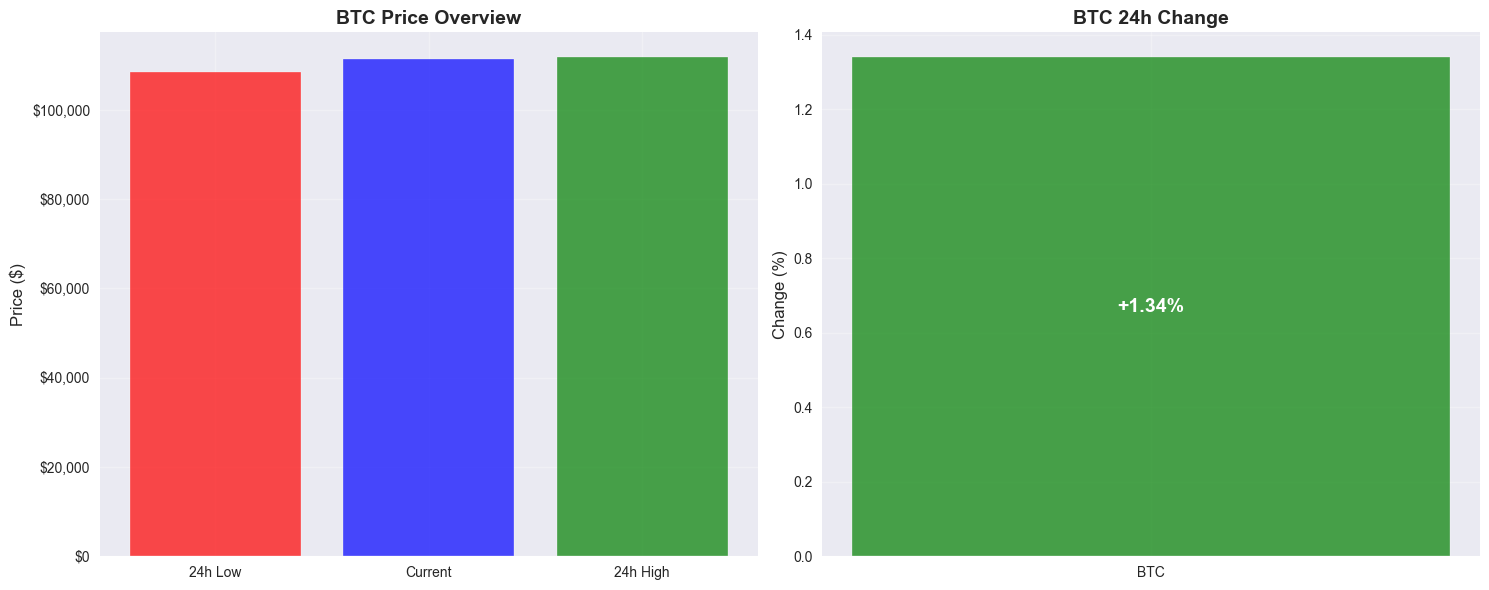


📊 BTC Summary:
       Metric       Value
       Ticker         BTC
Current Price $111,436.34
   24h Change      +1.34%
     24h High $111,782.21
      24h Low $108,393.39
   24h Volume      16,384


In [7]:
# Create price visualization
if ticker and price_data and price_data.get('success'):
    try:
        # Create a simple price chart
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Price overview
        prices = [price_data['low_24h'], price_data['current_price'], price_data['high_24h']]
        labels = ['24h Low', 'Current', '24h High']
        colors = ['red', 'blue', 'green']
        
        ax1.bar(labels, prices, color=colors, alpha=0.7)
        ax1.set_title(f'{ticker} Price Overview', fontsize=14, fontweight='bold')
        ax1.set_ylabel('Price ($)', fontsize=12)
        ax1.grid(True, alpha=0.3)
        
        # Format y-axis to show prices nicely
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
        
        # 24h change indicator
        change = price_data['price_change_24h']
        color = 'green' if change > 0 else 'red'
        ax2.bar([ticker], [abs(change)], color=color, alpha=0.7)
        ax2.set_title(f'{ticker} 24h Change', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Change (%)', fontsize=12)
        ax2.text(0, abs(change)/2, f'{change:+.2f}%', ha='center', va='center', 
                fontsize=14, fontweight='bold', color='white')
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Summary table
        summary_data = {
            'Metric': ['Ticker', 'Current Price', '24h Change', '24h High', '24h Low', '24h Volume'],
            'Value': [
                ticker,
                f"${price_data['current_price']:,.2f}",
                f"{price_data['price_change_24h']:+.2f}%",
                f"${price_data['high_24h']:,.2f}",
                f"${price_data['low_24h']:,.2f}",
                f"{price_data['volume_24h']:,.0f}"
            ]
        }
        
        df_summary = pd.DataFrame(summary_data)
        print(f"\n📊 {ticker} Summary:")
        print(df_summary.to_string(index=False))
        
    except Exception as e:
        print(f"❌ Error creating visualization: {e}")
else:
    print("❌ Cannot create visualization without valid price data")

## 5. Historical Data Analysis (1 Month)

📈 Fetching 7-day historical data for BTC...
✅ Historical data fetched: 7 records


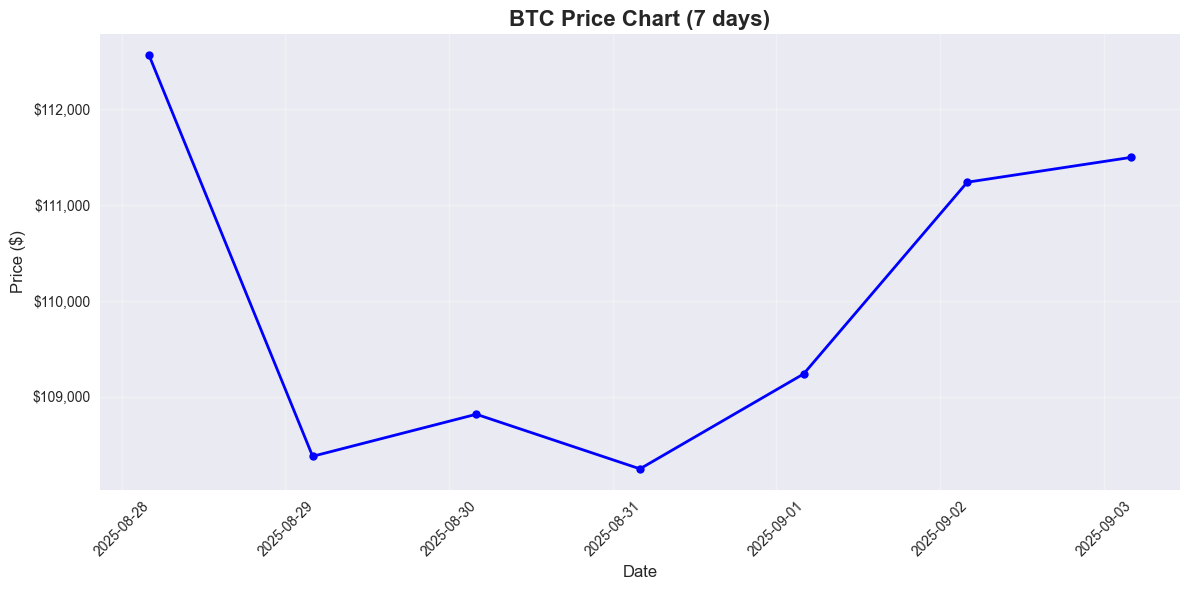


📋 Recent BTC data:
          timestamp      open      high       low     close      volume
2025-08-30 04:00:00 108377.40 108926.15 107350.10 108816.33 10708.39159
2025-08-31 04:00:00 108816.33 109480.02 108076.93 108246.35  9489.51596
2025-09-01 04:00:00 108246.36 109912.40 107255.00 109237.42 16053.60219
2025-09-02 04:00:00 109237.43 111771.52 108393.39 111240.01 18510.28756
2025-09-03 04:00:00 111240.01 111782.21 110528.71 111499.18  5139.12870


In [8]:
# Get historical data if ticker is available
if ticker:
    print(f"📈 Fetching 30-day historical data for {ticker}...")
    try:
        historical_data = binance_api.get_historical_data(ticker, interval='1d', days=30)
        
        if historical_data.get('success'):
            data_list = historical_data['data']  # This is a list of dictionaries
            print(f"✅ Historical data fetched: {len(data_list)} records")

            # Convert to pandas DataFrame for easier handling
            df_history = pd.DataFrame(data_list)

            # Simple price chart
            plt.figure(figsize=(12, 6))
            plt.plot(df_history['timestamp'], df_history['close'],
                    marker='o', linewidth=2, markersize=6, color='blue')
            plt.title(f'{ticker} Price Chart (30 days)', fontsize=16, fontweight='bold')
            plt.xlabel('Date', fontsize=12)
            plt.ylabel('Price ($)', fontsize=12)
            plt.xticks(rotation=45)
            plt.grid(True, alpha=0.3)

            # Format y-axis
            plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

            plt.tight_layout()
            plt.show()

            # Enhanced Analysis with Multiple Charts
            fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

            # 1. Price with Moving Averages
            ax1.plot(df_history['timestamp'], df_history['close'], label='Close Price', linewidth=2, color='blue')
            if 'sma_7' in df_history.columns:
                ax1.plot(df_history['timestamp'], df_history['sma_7'], label='7-day SMA', linewidth=1, color='orange', alpha=0.8)
            if 'sma_30' in df_history.columns:
                ax1.plot(df_history['timestamp'], df_history['sma_30'], label='30-day SMA', linewidth=1, color='red', alpha=0.8)
            ax1.set_title(f'{ticker} Price with Moving Averages', fontweight='bold')
            ax1.set_ylabel('Price ($)')
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            ax1.tick_params(axis='x', rotation=45)

            # 2. Daily Price Changes
            if 'price_change' in df_history.columns:
                colors = ['green' if x > 0 else 'red' for x in df_history['price_change']]
                ax2.bar(df_history['timestamp'], df_history['price_change'], color=colors, alpha=0.7)
                ax2.set_title(f'{ticker} Daily Price Changes (%)', fontweight='bold')
                ax2.set_ylabel('Change (%)')
                ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
                ax2.grid(True, alpha=0.3)
                ax2.tick_params(axis='x', rotation=45)

            # 3. Volume Analysis
            ax3.bar(df_history['timestamp'], df_history['volume'], color='purple', alpha=0.6)
            ax3.set_title(f'{ticker} Trading Volume', fontweight='bold')
            ax3.set_ylabel('Volume')
            ax3.grid(True, alpha=0.3)
            ax3.tick_params(axis='x', rotation=45)

            # 4. High-Low Range
            ax4.fill_between(df_history['timestamp'], df_history['low'], df_history['high'],
                           alpha=0.3, color='gray', label='Daily Range')
            ax4.plot(df_history['timestamp'], df_history['close'], color='blue', linewidth=2, label='Close')
            ax4.set_title(f'{ticker} Price Range (High-Low)', fontweight='bold')
            ax4.set_ylabel('Price ($)')
            ax4.legend()
            ax4.grid(True, alpha=0.3)
            ax4.tick_params(axis='x', rotation=45)

            plt.tight_layout()
            plt.show()

            # Calculate and display analysis metrics
            print(f"\n📊 {ticker} 30-Day Analysis Summary:")
            print("=" * 50)

            # Price statistics
            current_price = df_history['close'].iloc[-1]
            month_start_price = df_history['close'].iloc[0]
            month_return = ((current_price / month_start_price) - 1) * 100

            max_price = df_history['high'].max()
            min_price = df_history['low'].min()
            avg_price = df_history['close'].mean()

            print(f"💰 Price Analysis:")
            print(f"   Current Price: ${current_price:,.2f}")
            print(f"   Month Start: ${month_start_price:,.2f}")
            print(f"   Monthly Return: {month_return:+.2f}%")
            print(f"   30-Day High: ${max_price:,.2f}")
            print(f"   30-Day Low: ${min_price:,.2f}")
            print(f"   Average Price: ${avg_price:,.2f}")

            # Volatility analysis
            if 'price_change' in df_history.columns:
                daily_changes = df_history['price_change'].dropna()
                volatility = daily_changes.std()
                avg_daily_change = daily_changes.mean()
                positive_days = (daily_changes > 0).sum()
                negative_days = (daily_changes < 0).sum()

                print(f"\n📈 Volatility Analysis:")
                print(f"   Daily Volatility: {volatility:.2f}%")
                print(f"   Avg Daily Change: {avg_daily_change:+.2f}%")
                print(f"   Positive Days: {positive_days} ({positive_days/len(daily_changes)*100:.1f}%)")
                print(f"   Negative Days: {negative_days} ({negative_days/len(daily_changes)*100:.1f}%)")

            # Volume analysis
            avg_volume = df_history['volume'].mean()
            max_volume = df_history['volume'].max()
            recent_volume = df_history['volume'].tail(7).mean()  # Last 7 days average

            print(f"\n📦 Volume Analysis:")
            print(f"   30-Day Avg Volume: {avg_volume:,.0f}")
            print(f"   Max Volume: {max_volume:,.0f}")
            print(f"   Recent 7-Day Avg: {recent_volume:,.0f}")
            print(f"   Volume Trend: {'📈 Increasing' if recent_volume > avg_volume else '📉 Decreasing'}")

            # Show recent data
            print(f"\n📋 Recent {ticker} data (Last 5 days):")
            display_cols = ['timestamp', 'open', 'high', 'low', 'close', 'volume']
            if 'price_change' in df_history.columns:
                display_cols.append('price_change')
            print(df_history[display_cols].tail().to_string(index=False))
            
        else:
            print(f"❌ Failed to fetch historical data: {historical_data.get('error')}")
    except Exception as e:
        print(f"❌ Error fetching historical data: {e}")
else:
    print("❌ Cannot fetch historical data without valid ticker")

## 6. Summary and Next Steps

In [9]:
print("🎉 Query Processing Complete!")
print("=" * 40)

if ticker and price_data and price_data.get('success'):
    print(f"✅ Successfully processed query for {ticker}")
    print(f"💰 Current Price: ${price_data['current_price']:,.2f}")
    print(f"📈 24h Change: {price_data['price_change_24h']:+.2f}%")
    print(f"🤖 AI Analysis: Completed")
else:
    print("❌ Query processing incomplete")

print("\n🚀 Next Steps:")
print("   • Try different crypto queries by changing the user_query variable")
print("   • Use the Gradio app for easier interaction")
print("   • Explore historical data analysis")
print("   • Build paper trading features")
print("\n💡 Tips:")
print("   • Make sure your .env file has valid API keys")
print("   • Check internet connection for API calls")
print("   • Restart kernel if you encounter import issues")

🎉 Query Processing Complete!
✅ Successfully processed query for BTC
💰 Current Price: $111,436.34
📈 24h Change: +1.34%
🤖 AI Analysis: Completed

🚀 Next Steps:
   • Try different crypto queries by changing the user_query variable
   • Use the Gradio app for easier interaction
   • Explore historical data analysis
   • Build paper trading features

💡 Tips:
   • Make sure your .env file has valid API keys
   • Check internet connection for API calls
   • Restart kernel if you encounter import issues
